#Time Series Basics
### Project: Monthly Sales Time Series Analysis

This notebook introduces the basic concepts of time series analysis using a monthly sales dataset.

The analysis covers:

- Understanding time series data
- Trend and seasonality
- Time-based aggregation
- Monthly resampling
- Rolling averages
- Simple moving-average forecasting
- Basic linear-trend forecasting
- Interpretation of time-series patterns

## 2. Introduction to Time Series

Time series data consists of observations collected over time.
Examples include:
- Daily temperature
- Monthly sales
- Weekly website visits
- Daily stock prices
- Yearly population
- Hourly electricity usage

Time series data is different from ordinary tabular data because the order of observations matters.
For example, monthly sales from January, February, and March have a natural chronological order.
Two important concepts are:

### Trend

A trend is the general long-term direction of the data. For example, sales may generally increase over several years.

### Seasonality

Seasonality is a repeating pattern that occurs at regular time intervals. For example, a business may experience higher sales every December because of holiday shopping. In this notebook, I will analyze both trend and seasonality using monthly sales data.

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## Creating the sales Dataset

In [2]:
sales_data = {
    "date": pd.date_range(
        start="2023-01-01",
        periods=36,
        freq="MS"
    ),
    "sales": [
        120, 135, 128, 145, 155, 170,
        165, 175, 185, 195, 210, 240,
        145, 155, 150, 165, 175, 190,
        185, 195, 205, 215, 230, 260,
        170, 180, 175, 190, 200, 215,
        210, 220, 235, 245, 260, 290
    ]
}

sales_df = pd.DataFrame(sales_data)

sales_df.head()

,date,sales
0,2023-01-01,120
1,2023-02-01,135
2,2023-03-01,128
3,2023-04-01,145
4,2023-05-01,155


### Understanding the datasets


In [3]:
print("Dataset shape:", sales_df.shape)

print("\nColumn names:")
print(sales_df.columns.tolist())

print("\nData types:")
print(sales_df.dtypes)

print("\nDataset information:")
print(sales_df.info())

Dataset shape: (36, 2)

Column names:
['date', 'sales']

Data types:
date     datetime64[ns]
sales             int64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    36 non-null     datetime64[ns]
 1   sales   36 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 708.0 bytes
None


### Converting the Date Column

In [4]:
sales_df["date"] = pd.to_datetime(sales_df["date"])

print(sales_df.dtypes)

date     datetime64[ns]
sales             int64
dtype: object


### Setting  Date as the Time-Series Index

In [5]:
sales_ts = sales_df.set_index("date")

sales_ts.head()

,sales
date,
2023-01-01,120
2023-02-01,135
2023-03-01,128
2023-04-01,145
2023-05-01,155


In [6]:
print("Index type:")
print(type(sales_ts.index))

print("\nFrequency:")
print(sales_ts.index.freq)

Index type:
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>

Frequency:
None


### Exploring the Time Range

In [7]:
print("Start date:", sales_ts.index.min())
print("End date:", sales_ts.index.max())

print("Number of observations:", len(sales_ts))

Start date: 2023-01-01 00:00:00
End date: 2025-12-01 00:00:00
Number of observations: 36


In [8]:
# Basic Statistical Summary
sales_ts.describe()

,sales
count,36.000000
mean,191.194444
std,39.629585
min,120.000000
25%,165.000000
50%,187.500000
75%,215.000000
max,290.000000


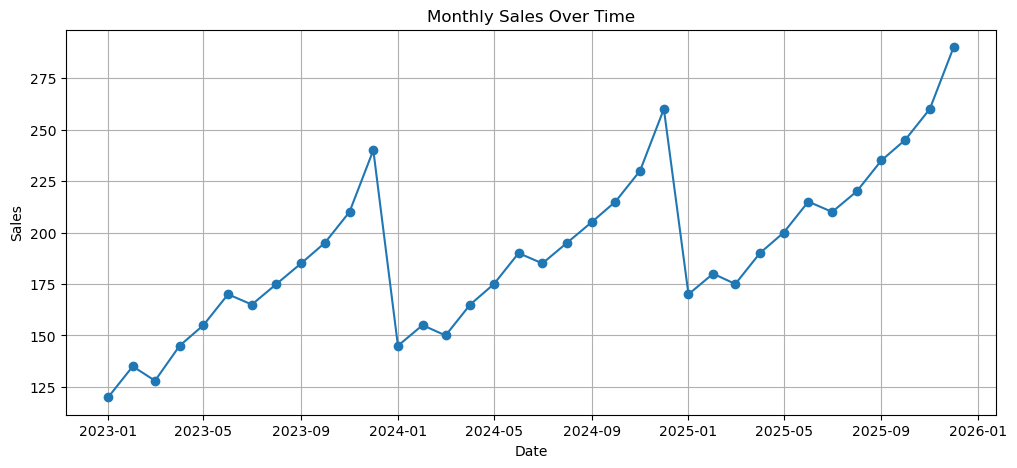

In [9]:
# Plot Sales Over Time
plt.figure(figsize=(12, 5))

plt.plot(
    sales_ts.index,
    sales_ts["sales"],
    marker="o"
)

plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

## 3. Identifying the Trend

A trend represents the general long-term direction of a time series.

From the sales plot, the overall sales level increases from 2023 to 2025.

This suggests an upward trend.

However, individual months do not always increase smoothly. Some months have lower sales than the previous month.

Therefore, it is useful to smooth short-term fluctuations using a rolling average.

In [10]:
sales_ts["rolling_3_month"] = (
    sales_ts["sales"]
    .rolling(window=3)
    .mean()
)

sales_ts.head(10)

,sales,rolling_3_month
date,,
2023-01-01,120,NaN
2023-02-01,135,NaN
2023-03-01,128,127.666667
2023-04-01,145,136.000000
2023-05-01,155,142.666667
2023-06-01,170,156.666667
2023-07-01,165,163.333333
2023-08-01,175,170.000000
2023-09-01,185,175.000000


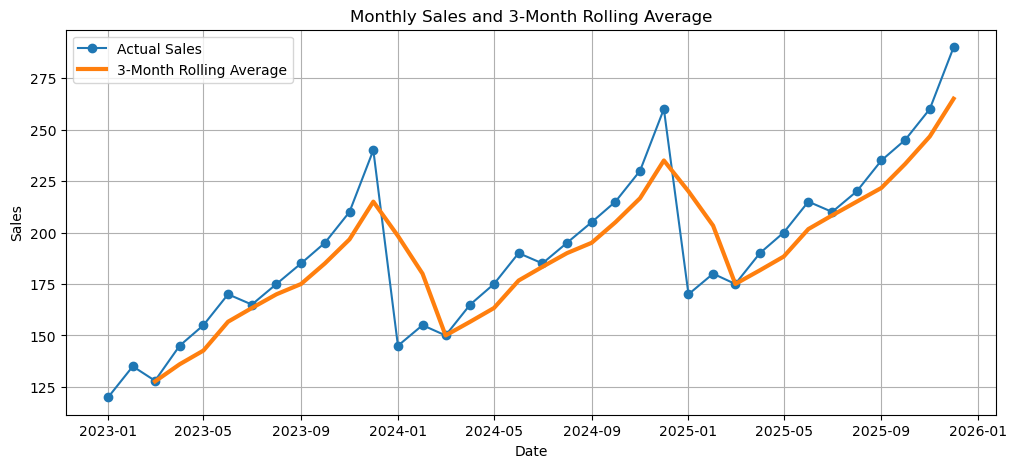

In [11]:
# Visualizing the Rolling Average
plt.figure(figsize=(12, 5))

plt.plot(
    sales_ts.index,
    sales_ts["sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    sales_ts.index,
    sales_ts["rolling_3_month"],
    linewidth=3,
    label="3-Month Rolling Average"
)

plt.title("Monthly Sales and 3-Month Rolling Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

## 4. Understanding Seasonality

Seasonality refers to a pattern that repeats at a regular time interval.

In monthly business data, seasonality may occur because of:

- holidays
- weather
- school schedules
- festivals
- customer purchasing habits
- yearly business cycles

In this dataset, sales tend to be higher toward the end of each year.

This repeated yearly pattern suggests possible annual seasonality.

The dataset is designed for learning purposes, so the seasonal pattern should be treated as an example rather than evidence about a real business.

In [12]:
# Time-based Aggregation
yearly_sales = sales_ts["sales"].resample("YS").sum()

print("Yearly Sales:")
print(yearly_sales)

Yearly Sales:
date
2023-01-01    2023
2024-01-01    2270
2025-01-01    2590
Freq: YS-JAN, Name: sales, dtype: int64


In [13]:
# calculating yearly average sales
yearly_average_sales = sales_ts["sales"].resample("YS").mean()

print("Average Monthly Sales by Year:")
print(yearly_average_sales)

Average Monthly Sales by Year:
date
2023-01-01    168.583333
2024-01-01    189.166667
2025-01-01    215.833333
Freq: YS-JAN, Name: sales, dtype: float64


In [14]:
# Monthly Resampling
monthly_sales = sales_ts["sales"].resample("MS").mean()

monthly_sales.head(12)

date
2023-01-01    120.0
2023-02-01    135.0
2023-03-01    128.0
2023-04-01    145.0
2023-05-01    155.0
2023-06-01    170.0
2023-07-01    165.0
2023-08-01    175.0
2023-09-01    185.0
2023-10-01    195.0
2023-11-01    210.0
2023-12-01    240.0
Freq: MS, Name: sales, dtype: float64

In [15]:
# Weekly Resampling
weekly_sales = sales_ts["sales"].resample("W").mean()

weekly_sales.head(10)

date
2023-01-01    120.0
2023-01-08      NaN
2023-01-15      NaN
2023-01-22      NaN
2023-01-29      NaN
2023-02-05    135.0
2023-02-12      NaN
2023-02-19      NaN
2023-02-26      NaN
2023-03-05    128.0
Freq: W-SUN, Name: sales, dtype: float64

## 5. Simple Moving-Average Forecast

A moving-average forecast uses recent observations to estimate the next value.

For example, a 3-month moving average uses the previous three months of sales.

This method is simple and useful for demonstrating the basic idea of forecasting.

It does not capture all possible changes in a time series, so it should not be treated as a sophisticated forecasting model.

In [16]:
sales_ts["moving_average_forecast"] = (
    sales_ts["sales"]
    .rolling(window=3)
    .mean()
    .shift(1)
)

sales_ts.tail(10)

,sales,rolling_3_month,moving_average_forecast
date,,,
2025-03-01,175,175.000000,203.333333
2025-04-01,190,181.666667,175.000000
2025-05-01,200,188.333333,181.666667
2025-06-01,215,201.666667,188.333333
2025-07-01,210,208.333333,201.666667
2025-08-01,220,215.000000,208.333333
2025-09-01,235,221.666667,215.000000
2025-10-01,245,233.333333,221.666667
2025-11-01,260,246.666667,233.333333


### Plot Actual Sales vs Moving-Average Forecast

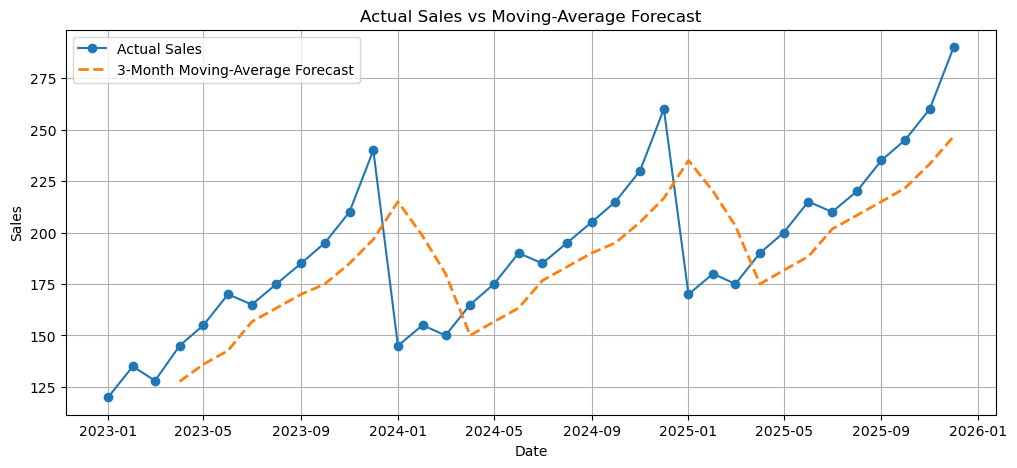

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    sales_ts.index,
    sales_ts["sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    sales_ts.index,
    sales_ts["moving_average_forecast"],
    linestyle="--",
    linewidth=2,
    label="3-Month Moving-Average Forecast"
)

plt.title("Actual Sales vs Moving-Average Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

## 6. Basic Linear Trend

Another simple forecasting approach is to fit a straight line to the historical sales data.

The linear trend attempts to describe the overall direction of sales over time.

This approach is useful when the main pattern in the data is a gradual increase or decrease.

It is a simple educational forecasting method and does not account for more complex seasonal patterns.

In [18]:
sales_trend = sales_ts[["sales"]].copy()

sales_trend["time_index"] = np.arange(len(sales_trend))

sales_trend.head()

,sales,time_index
date,,
2023-01-01,120,0
2023-02-01,135,1
2023-03-01,128,2
2023-04-01,145,3
2023-05-01,155,4


In [19]:
# Fit the Linear Trend
trend_model = np.polyfit(
    sales_trend["time_index"],
    sales_trend["sales"],
    1
)

trend_slope = trend_model[0]
trend_intercept = trend_model[1]

sales_trend["linear_trend"] = (
    trend_slope * sales_trend["time_index"]
    + trend_intercept
)

print("Trend slope:", trend_slope)
print("Trend intercept:", trend_intercept)

Trend slope: 2.8039897039897017
Trend intercept: 142.1246246246246


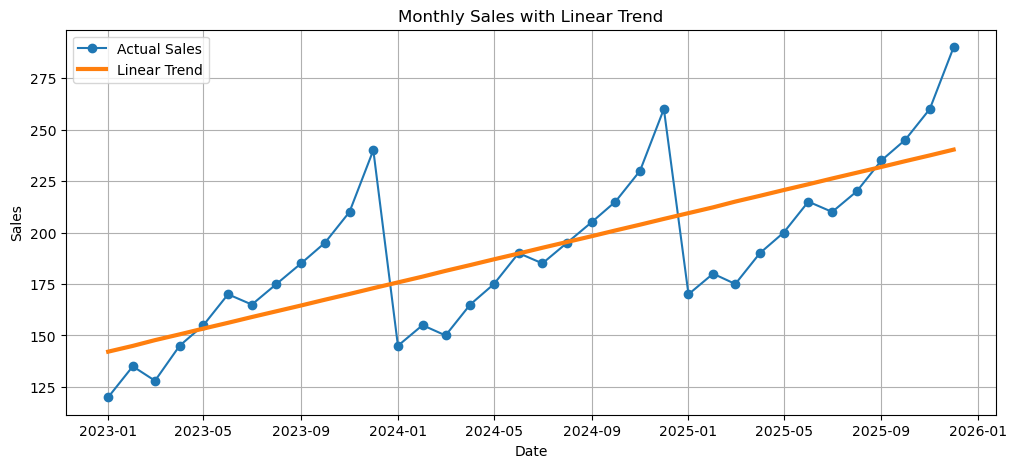

In [20]:
# Visualize the Linear Trend
plt.figure(figsize=(12, 5))

plt.plot(
    sales_trend.index,
    sales_trend["sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    sales_trend.index,
    sales_trend["linear_trend"],
    linewidth=3,
    label="Linear Trend"
)

plt.title("Monthly Sales with Linear Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

### Trend Interpretation

The fitted linear trend has a positive slope, indicating that sales generally increased over the three-year period.

The actual monthly sales do not follow the trend perfectly because individual months contain short-term fluctuations.

The linear trend therefore provides a simplified description of the long-term direction rather than an exact prediction for every month.

In [21]:
# Forecast Future Months Using the Linear Trend
# Now we'll use the trend to estimate the next six months.
future_periods = 6

future_time_index = np.arange(
    len(sales_trend),
    len(sales_trend) + future_periods
)

future_dates = pd.date_range(
    start=sales_trend.index[-1] + pd.offsets.MonthBegin(1),
    periods=future_periods,
    freq="MS"
)

future_predictions = (
    trend_slope * future_time_index
    + trend_intercept
)

future_trend_forecast = pd.DataFrame({
    "date": future_dates,
    "forecast_sales": future_predictions
})

future_trend_forecast

,date,forecast_sales
0,2026-01-01,243.068254
1,2026-02-01,245.872244
2,2026-03-01,248.676233
3,2026-04-01,251.480223
4,2026-05-01,254.284213
5,2026-06-01,257.088202


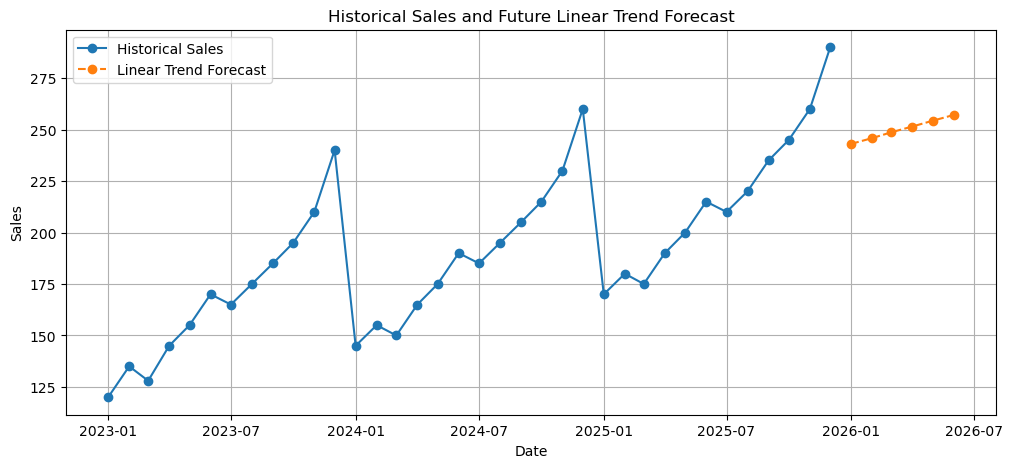

In [22]:
# Plot Historical Data and Future Forecast
plt.figure(figsize=(12, 5))

plt.plot(
    sales_ts.index,
    sales_ts["sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    future_trend_forecast["date"],
    future_trend_forecast["forecast_sales"],
    marker="o",
    linestyle="--",
    label="Linear Trend Forecast"
)

plt.title("Historical Sales and Future Linear Trend Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

## 7. Comparing the Simple Forecasting Methods

Two simple approaches were demonstrated:

### 1. Moving-Average Forecast

The moving-average method uses recent observations to estimate the next value.

Advantages:

- Simple to understand.
- Responds to recent observations.
- Smooths short-term fluctuations.

Limitation:

- It may lag behind a strong long-term trend.

### 2. Linear-Trend Forecast

The linear-trend method fits a straight line through the historical observations.

Advantages:

- Clearly represents the overall direction of the data.
- Simple to use for a steadily increasing or decreasing series.

Limitation:

- It does not explicitly model seasonal patterns.
- Real-world data may not continue following a straight-line trend.

These methods are used here as introductory forecasting techniques rather than advanced production forecasting models.

In [24]:
# Creating a Forecast Summary Table
forecast_summary = future_trend_forecast.copy()

forecast_summary["forecast_sales"] = (
    forecast_summary["forecast_sales"].round(2)
)

forecast_summary

,date,forecast_sales
0,2026-01-01,243.07
1,2026-02-01,245.87
2,2026-03-01,248.68
3,2026-04-01,251.48
4,2026-05-01,254.28
5,2026-06-01,257.09


In [26]:
# calculate iverall Sales Growth
first_sales = sales_ts["sales"].iloc[0]
last_sales = sales_ts["sales"].iloc[-1]

absolute_change = last_sales - first_sales

percentage_change = (
    absolute_change / first_sales
) * 100

print("First recorded monthly sales:", first_sales)
print("Last recorded monthly sales:", last_sales)
print("Absolute change:", absolute_change)
print("Percentage change:", round(percentage_change, 2), "%")

First recorded monthly sales: 120
Last recorded monthly sales: 290
Absolute change: 170
Percentage change: 141.67 %


In [27]:
# Identifying the highest and lowest sales months 
highest_sales_date = sales_ts["sales"].idxmax()
highest_sales_value = sales_ts["sales"].max()

lowest_sales_date = sales_ts["sales"].idxmin()
lowest_sales_value = sales_ts["sales"].min()

print("Highest sales:")
print(highest_sales_date, "->", highest_sales_value)

print("\nLowest sales:")
print(lowest_sales_date, "->", lowest_sales_value)

Highest sales:
2025-12-01 00:00:00 -> 290

Lowest sales:
2023-01-01 00:00:00 -> 120


### Analyzing Yearly Changes 

In [28]:
yearly_summary = pd.DataFrame({
    "Total Sales": sales_ts["sales"].resample("YS").sum(),
    "Average Monthly Sales": sales_ts["sales"].resample("YS").mean()
})

yearly_summary

,Total Sales,Average Monthly Sales
date,,
2023-01-01,2023,168.583333
2024-01-01,2270,189.166667
2025-01-01,2590,215.833333


### Visualizing Yearly Average Sales

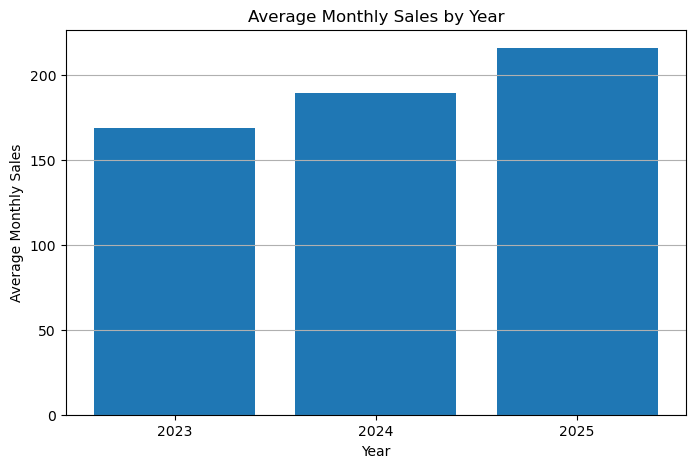

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    yearly_summary.index.year.astype(str),
    yearly_summary["Average Monthly Sales"]
)

plt.title("Average Monthly Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Monthly Sales")
plt.grid(axis="y")

plt.show()

## 9. Possible Explanations for the Observed Pattern

The upward trend in this educational dataset could represent factors such as:

- gradual growth in customer demand,
- an increase in the number of customers,
- business expansion,
- improved marketing,
- increasing product sales over time.

The repeated higher sales toward the end of the year could represent seasonal factors such as holidays, festivals, promotional campaigns, or changes in customer purchasing behavior.

Because this is a synthetic educational dataset, these explanations are possible interpretations rather than verified causes.

## 10. Final Summary

This project analyzed a monthly sales time series covering three years.

The analysis showed an overall upward trend in sales, although monthly values fluctuated over time. A 3-month rolling average was used to smooth short-term fluctuations and make the underlying trend easier to observe.

Time-based aggregation was performed using Pandas resampling. Yearly totals and average monthly sales were calculated, and monthly and weekly resampling techniques were demonstrated.

The data also showed a repeating pattern of relatively higher sales toward the end of each year, providing an example of possible seasonality.

Two simple forecasting approaches were demonstrated. The first was a 3-month moving-average forecast, which uses recent observations. The second was a basic linear-trend forecast, which estimates future values from the overall historical direction.

The analysis demonstrates the basic workflow of time-series analysis: organize the dates correctly, visualize the data, identify trends and seasonal patterns, aggregate observations over time, smooth the series, and apply a simple forecasting method.

Because the dataset is synthetic and the forecasting methods are simple, the results should be considered educational rather than production-level business forecasts.

In [ ]:
## 11. Week 9 Completion Checklist

-  Understood what makes time series different from regular tabular data.
-  Studied trend.
-  Studied seasonality.
-  Created and explored a time-series dataset.
-  Converted the date column to datetime.
-  Created a DatetimeIndex.
-  Performed time-based aggregation.
-  Performed monthly resampling.
-  Demonstrated weekly resampling.
-  Calculated a rolling average.
-  Created a moving-average forecast.
-  Created a basic linear-trend forecast.
-  Forecasted future periods.
-  Visualized the forecasts.
-  Calculated overall sales growth.
-  Identified important observations.
-  Wrote key findings.
-  Discussed possible explanations for the observed pattern.
-  Added a final written summary.

The Week 9 notebook now covers the required Time Series Basics tasks and includes both analysis and written interpretation.